In [1]:
import pykasso as pk
import numpy   as np

In [20]:
# First create grid object
x0, y0 ,z0 = 0, 0, 0
nx, ny, nz = 1000, 1000, 10
dx, dy, dz = 10, 10, 10

grid = pk.Grid(x0,y0,z0,nx,ny,nz,dx,dy,dz)

In [21]:
# Set a seed (for reproducibility)
seed = 1
np.random.seed(seed)

In [22]:
# Then create geology manager
geology = pk.GeologyManager(grid)

### Geology

### Topography

### Orientation

### Faults

### Fractures

In [23]:
# Set "geology", "topography", "orientation", "faults" and "fractures" data
geology.set_data_null("geology")
geology.set_data_null("topography")
geology.set_data_null("orientation")
geology.set_data_null("faults")
geology.set_data_null("fractures")

In [24]:
# Fracture generation settings
fractures_densities = [0.0001]
fractures_alpha = [2]
fractures_min_orientation = [130]
fractures_max_orientation = [150]
fractures_min_dip = [0]
fractures_max_dip = [10]
fractures_min_length = [100]
fractures_max_length = [1000]

In [25]:
# Generate fractures
geology.generate_fractures(fractures_densities, fractures_alpha, 
                           fractures_min_orientation, fractures_max_orientation,
                           fractures_min_dip,fractures_max_dip,
                           fractures_min_length, fractures_max_length)

In [26]:
# Rasterize fractures
frac = geology.rasterize_fracture_network()

Rasterizing: 100%|██████████| 12074/12074 [00:21<00:00, 562.63it/s]


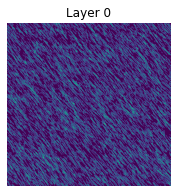

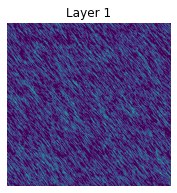

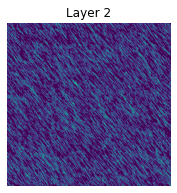

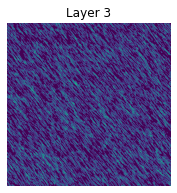

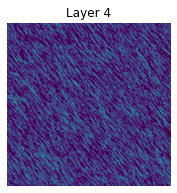

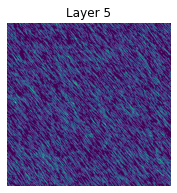

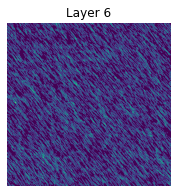

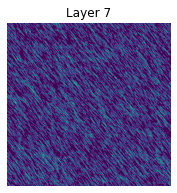

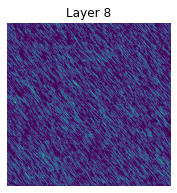

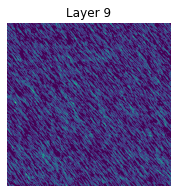

In [27]:
import matplotlib.pyplot as plt
for k in range(grid.nz):    
    plt.figure( figsize=(3,3) )
    plt.imshow(frac[k,:,:], origin='lower')
    plt.title('Layer '+str(k))
    plt.axis('off')
    plt.show()

In [8]:
# Fractures are stored in this list
geology.fractures

[[id:0, fam.:0, x:-54.87, y:277.57, z:-15.32, rad:5.45, or.:2.42, dip.:1.53] ,
 [id:1, fam.:0, x:169.9, y:910.93, z:-27.26, rad:12.61, or.:2.38, dip.:1.5] ,
 [id:2, fam.:0, x:289.77, y:706.55, z:57.64, rad:25.66, or.:2.43, dip.:1.52] ,
 [id:3, fam.:0, x:706.06, y:292.07, z:38.65, rad:20.09, or.:2.45, dip.:1.58] ,
 [id:4, fam.:0, x:58.55, y:437.68, z:60.86, rad:6.8, or.:2.4, dip.:1.41] ,
 [id:5, fam.:0, x:485.73, y:3.7, z:27.41, rad:5.76, or.:2.33, dip.:1.45] ,
 [id:6, fam.:0, x:-0.05, y:534.49, z:36.38, rad:9.32, or.:2.43, dip.:1.51] ,
 [id:7, fam.:0, x:916.64, y:631.04, z:45.09, rad:7.29, or.:2.41, dip.:1.54] ,
 [id:8, fam.:0, x:439.9, y:581.23, z:10.81, rad:6.36, or.:2.44, dip.:1.44] ,
 [id:9, fam.:0, x:944.39, y:630.7, z:-28.42, rad:30.58, or.:2.47, dip.:1.56] ,
 [id:10, fam.:0, x:774.26, y:960.33, z:41.15, rad:5.63, or.:2.44, dip.:1.5] ]

[-0.030585338944769627, -0.026982340274954244, -0.9991678989814075]
[-0.053549409443232054, -0.05103085012918083, -0.9972604038481495]
[-0.04190880627934395, -0.03596203529176191, -0.9984740276912136]
[0.008554137086915839, 0.007143407786446232, -0.999937897303575]
[-0.11911934201017475, -0.10833989355968646, -0.9869513918235988]
[-0.08178719341690543, -0.08544417324379691, -0.9929804369934333]
[-0.04692570803153353, -0.040859767408580445, -0.9980623514255289]
[-0.01959090254237141, -0.017717754434862548, -0.9996510779843941]
[-0.10082481680909705, -0.08466576818539673, -0.991295144754068]
[-0.005913040119424545, -0.004736036535192596, -0.9999713025454697]
[-0.05385769707463464, -0.04542816249143059, -0.9975147269682133]


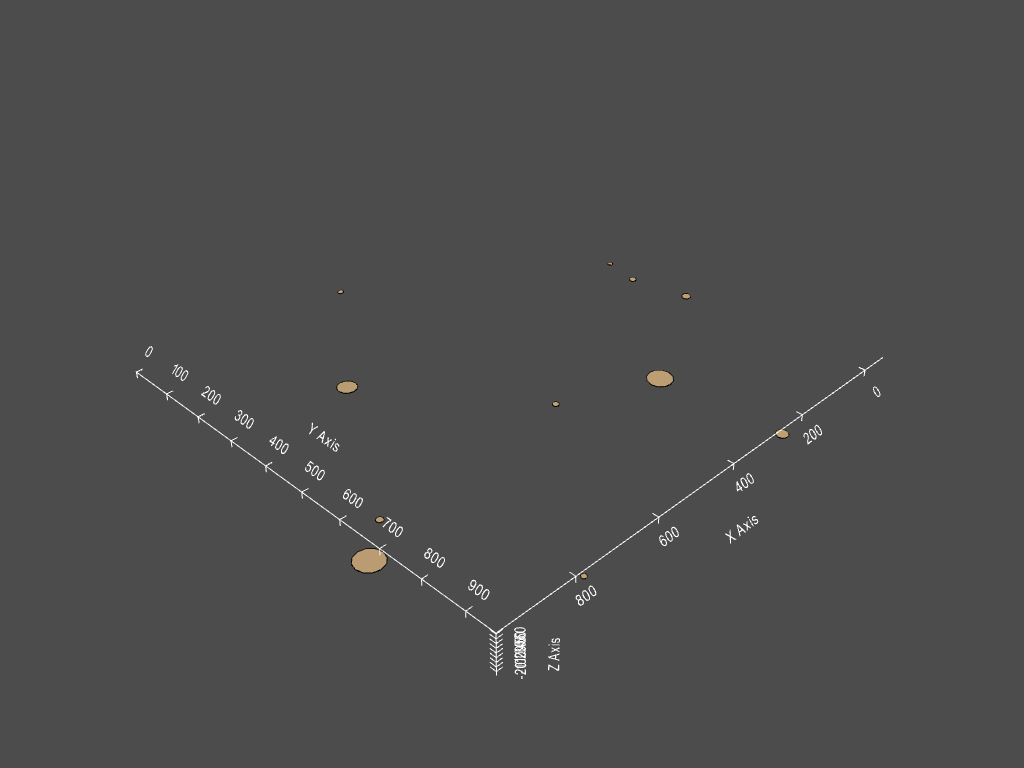

[(2041.3780439153181, 2066.011514450596, 1600.6966312184798),
 (457.3215675354004, 481.9550380706787, 16.64015483856201),
 (0.0, 0.0, 1.0)]

In [9]:
# Visualize fractures with pyvista
%matplotlib qt
import pyvista as pv
frac = geology.fractures

p = pv.Plotter()
for f in frac:
    x, y, z = f.get_position()
    a, b, c = f.get_normal()
    print(f.get_normal())
    pol = pv.Polygon(center=(x, y, z), radius=f.radius, normal=(a, b, c), n_sides=12)
    p.add_mesh(pol, color="tan", show_edges=True)
p.show_bounds()

p.show()

In [ ]:
geology.show()